In [2]:
import pandas as pd
pd.set_option('display.max_columns', None)


In [3]:
df = pd.read_csv('voos.csv', sep=';', header=1)
df.head()

,Data Referência UTC,Sigla ICAO Empresa Aérea,Nome da Empresa Aérea,Número Etapa,Número Voo,Sigla ICAO Modelo Aeronave,Quantidade de Assentos Previstos,Sigla ICAO Aeroporto Origem,Data Partida Prevista UTC,Sigla ICAO Aeroporto Destino,Data Chegada Prevista UTC,Tipo de Voo
0,01/12/2025 00:00:00,1ED,SERVICIOS AÉREOS PANAMERICANOS LTDA. SARPA S.A.S,1,3304,E145,50,SBEG,01/12/2025 00:50:00,SKBO,01/12/2025 03:45:00,NÃO REGULAR DE PASSAGEIROS INTERNACIONAL
1,01/12/2025 00:00:00,AAL,"AMERICAN AIRLINES, INC.",1,0904,B772,288,SBGL,01/12/2025 02:55:00,KMIA,01/12/2025 11:40:00,REGULAR DE PASSAGEIROS INTERNACIONAL
2,01/12/2025 00:00:00,AAL,"AMERICAN AIRLINES, INC.",1,0905,B772,288,KMIA,01/12/2025 04:00:00,SBGL,01/12/2025 12:25:00,REGULAR DE PASSAGEIROS INTERNACIONAL
3,01/12/2025 00:00:00,AAL,"AMERICAN AIRLINES, INC.",1,0906,B788,295,SBGR,01/12/2025 03:15:00,KMIA,01/12/2025 11:35:00,REGULAR DE PASSAGEIROS INTERNACIONAL
4,01/12/2025 00:00:00,AAL,"AMERICAN AIRLINES, INC.",1,0925,B788,295,KMIA,01/12/2025 03:35:00,SBGR,01/12/2025 11:50:00,REGULAR DE PASSAGEIROS INTERNACIONAL


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 920477 entries, 0 to 920476
Data columns (total 12 columns):
 #   Column                            Non-Null Count   Dtype
---  ------                            --------------   -----
 0   Data Referência UTC               920477 non-null  str  
 1   Sigla ICAO Empresa Aérea          920477 non-null  str  
 2   Nome da Empresa Aérea             920477 non-null  str  
 3   Número Etapa                      920477 non-null  int64
 4   Número Voo                        920477 non-null  str  
 5   Sigla ICAO Modelo Aeronave        920477 non-null  str  
 6   Quantidade de Assentos Previstos  920477 non-null  int64
 7   Sigla ICAO Aeroporto Origem       920477 non-null  str  
 8   Data Partida Prevista UTC         920477 non-null  str  
 9   Sigla ICAO Aeroporto Destino      920477 non-null  str  
 10  Data Chegada Prevista UTC         920477 non-null  str  
 11  Tipo de Voo                       920477 non-null  str  
dtypes: int64(2), str(10)
memory

In [5]:
df['Data Referência UTC'] = pd.to_datetime(df['Data Referência UTC'], errors='coerce')
df['Data Partida Prevista UTC'] = pd.to_datetime(df['Data Partida Prevista UTC'], errors='coerce')
df['Data Chegada Prevista UTC'] = pd.to_datetime(df['Data Chegada Prevista UTC'], errors='coerce')

In [6]:
df['Número Etapa'] = df['Número Etapa'].astype(int)
df['Quantidade de Assentos Previstos'] = df['Quantidade de Assentos Previstos'].astype(int)

In [7]:
df['Data Referência UTC'].value_counts()

Data Referência UTC
2025-01-12    3050
2026-08-01    3046
2025-04-12    3044
2026-05-01    3044
2025-08-12    3042
              ... 
2026-01-12     831
2026-02-12     826
2026-07-11     762
2026-01-11     745
2026-08-11     745
Name: count, Length: 146, dtype: int64

In [8]:
df_voo = df[
    (df['Data Referência UTC'] < '2026-01-01') &
    (df['Data Referência UTC'] > '2025-01-01')
    ].copy()
df_voo.shape

(35021, 12)

In [9]:
df_voo['Tipo de Voo'].value_counts()

Tipo de Voo
REGULAR DE PASSAGEIROS DOMÉSTICA                     26435
REGULAR DE PASSAGEIROS INTERNACIONAL                  5274
SOBREVOOS OU TRASLADOS OPERACIONAIS INTERNACIONAL     2098
REGULAR DE CARGA INTERNACIONAL                         457
REGULAR DE CARGA DOMÉSTICA                             429
NÃO REGULAR DE CARGA DOMÉSTICA                         108
NÃO REGULAR DE PASSAGEIROS DOMÉSTICA                    96
REGULAR DE CARGA DE CORREIO DOMÉSTICA                   54
NÃO REGULAR DE PASSAGEIROS INTERNACIONAL                42
SOBREVOOS OU TRASLADOS OPERACIONAIS DOMÉSTICA           15
NÃO REGULAR DE CARGA INTERNACIONAL                       9
REGULAR DE CARGA OU CORREIO INTERNACIONAL                4
Name: count, dtype: int64

In [10]:
df_voo = df_voo[df_voo['Tipo de Voo'] == 'REGULAR DE PASSAGEIROS DOMÉSTICA']

In [11]:
df_pub = pd.read_csv('AerodromosPublicos.csv', sep=';', header=1)
df_pub.columns

Index(['CÓDIGO OACI', 'CIAD', 'NOME', 'MUNICÍPIO ATENDIDO', 'UF', 'LATITUDE',
       'LONGITUDE', 'ALTITUDE', 'OPERAÇÃO', 'OACI', 'AIP BRASIL', 'DESIGNAÇÃO',
       'COMPRIMENTO', 'LARGURA', 'RESISTÊNCIA', 'SUPERFÍCIE', 'DESIGNAÇÃO.1',
       'COMPRIMENTO.1', 'LARGURA.1', 'RESISTÊNCIA.1', 'SUPERFÍCIE.1',
       'DESIGNAÇÃO.2', 'COMPRIMENTO.2', 'LARGURA.2', 'RESISTÊNCIA.2',
       'SUPERFÍCIE.2', 'RAMPA(S) DE APROXIMAÇÃO', 'FORMATO DA ÁREA DE POUSO',
       'DIMENSÕES', 'RESISTÊNCIA.3', 'SUPERFÍCIE.3', 'p1', 'p2', 'p3', 'p4',
       'PORTARIAS', 'Unnamed: 36', 'Unnamed: 37', 'Unnamed: 38',
       'PORTARIA Nº 16.739/2025 e alterações',
       'Portaria nº 17.388/2025\nA Classe I se divide ainda em RBAC 121, RBAC 135 Regular e Outras Operações',
       'PORTARIA Nº 2007/2014 E ALTERAÇÕES\n(* = REGIME TARIFÁRIO DIFERENCIADO)',
       'AERONAVE CRÍTICA', 'TIPO DE APROX. (CABECEIRAS)', 'CAT SESCINC', 'r1',
       'r2', 'REFERÊNCIA(S)', 'RESTRIÇÃO(ÕES)', 'SITUAÇÃO', 'r1.1',
       'REFERÊNCI

In [12]:
df_pub_origem = df_pub.rename(columns={
    'CÓDIGO OACI': 'origem_icao',
    'MUNICÍPIO ATENDIDO': 'origem_cidade',
    'UF': 'origem_uf',
    'LATITUDE': 'origem_lat',
    'LONGITUDE': 'origem_lon',
    'ALTITUDE': 'origem_alt'
})
df_pub_destino = df_pub.rename(columns={
    'CÓDIGO OACI': 'destino_icao',
    'MUNICÍPIO ATENDIDO': 'destino_cidade',
    'UF': 'destino_uf',
    'LATITUDE': 'destino_lat',
    'LONGITUDE': 'destino_lon',
    'ALTITUDE': 'destino_alt'
})


In [13]:
df_voo = pd.merge(
    df_voo,
    df_pub_origem[['origem_icao', 'origem_cidade', 'origem_uf', 'origem_lat', 'origem_lon', 'origem_alt']],
    left_on='Sigla ICAO Aeroporto Origem',
    right_on='origem_icao',
    how='left'
)

In [14]:
df_voo = pd.merge(
    df_voo,
    df_pub_destino[['destino_icao', 'destino_cidade', 'destino_uf', 'destino_lat', 'destino_lon', 'destino_alt']],
    left_on='Sigla ICAO Aeroporto Destino',
    right_on='destino_icao',
    how='left'
)
df_voo.head()

,Data Referência UTC,Sigla ICAO Empresa Aérea,Nome da Empresa Aérea,Número Etapa,Número Voo,Sigla ICAO Modelo Aeronave,Quantidade de Assentos Previstos,Sigla ICAO Aeroporto Origem,Data Partida Prevista UTC,Sigla ICAO Aeroporto Destino,Data Chegada Prevista UTC,Tipo de Voo,origem_icao,origem_cidade,origem_uf,origem_lat,origem_lon,origem_alt,destino_icao,destino_cidade,destino_uf,destino_lat,destino_lon,destino_alt
0,2025-01-12,ABJ,ATA - AEROTÁXI ABAETÉ LTDA.,1,1406,C208,9,SBSV,2025-01-12 16:00:00,SNCL,2025-01-12 16:30:00,REGULAR DE PASSAGEIROS DOMÉSTICA,SBSV,SALVADOR,BA,12° 54' 31'' S,38° 19' 21'' W,20 m,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-01-12,ABJ,ATA - AEROTÁXI ABAETÉ LTDA.,1,1407,C208,9,SNCL,2025-01-12 16:45:00,SBSV,2025-01-12 17:15:00,REGULAR DE PASSAGEIROS DOMÉSTICA,NaN,NaN,NaN,NaN,NaN,NaN,SBSV,SALVADOR,BA,12° 54' 31'' S,38° 19' 21'' W,20 m
2,2025-01-12,ABJ,ATA - AEROTÁXI ABAETÉ LTDA.,1,1408,C208,9,SBSV,2025-01-12 17:45:00,SNCL,2025-01-12 18:15:00,REGULAR DE PASSAGEIROS DOMÉSTICA,SBSV,SALVADOR,BA,12° 54' 31'' S,38° 19' 21'' W,20 m,NaN,NaN,NaN,NaN,NaN,NaN
3,2025-01-12,ABJ,ATA - AEROTÁXI ABAETÉ LTDA.,1,1409,C208,9,SDLO,2025-01-12 19:00:00,SBSV,2025-01-12 19:35:00,REGULAR DE PASSAGEIROS DOMÉSTICA,NaN,NaN,NaN,NaN,NaN,NaN,SBSV,SALVADOR,BA,12° 54' 31'' S,38° 19' 21'' W,20 m
4,2025-01-12,ABJ,ATA - AEROTÁXI ABAETÉ LTDA.,2,Z1408,C208,9,SNCL,2025-01-12 18:30:00,SDLO,2025-01-12 18:45:00,REGULAR DE PASSAGEIROS DOMÉSTICA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
df_voo = df_voo.dropna()
df_voo.info()

<class 'pandas.DataFrame'>
Index: 26177 entries, 5 to 26434
Data columns (total 24 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   Data Referência UTC               26177 non-null  datetime64[us]
 1   Sigla ICAO Empresa Aérea          26177 non-null  str           
 2   Nome da Empresa Aérea             26177 non-null  str           
 3   Número Etapa                      26177 non-null  int64         
 4   Número Voo                        26177 non-null  str           
 5   Sigla ICAO Modelo Aeronave        26177 non-null  str           
 6   Quantidade de Assentos Previstos  26177 non-null  int64         
 7   Sigla ICAO Aeroporto Origem       26177 non-null  str           
 8   Data Partida Prevista UTC         26177 non-null  datetime64[us]
 9   Sigla ICAO Aeroporto Destino      26177 non-null  str           
 10  Data Chegada Prevista UTC         26177 non-null  datetime64[u

In [16]:
df_voo.head()

,Data Referência UTC,Sigla ICAO Empresa Aérea,Nome da Empresa Aérea,Número Etapa,Número Voo,Sigla ICAO Modelo Aeronave,Quantidade de Assentos Previstos,Sigla ICAO Aeroporto Origem,Data Partida Prevista UTC,Sigla ICAO Aeroporto Destino,Data Chegada Prevista UTC,Tipo de Voo,origem_icao,origem_cidade,origem_uf,origem_lat,origem_lon,origem_alt,destino_icao,destino_cidade,destino_uf,destino_lat,destino_lon,destino_alt
5,2025-01-12,ACN,AZUL CONECTA LTDA. (EX TWO TAXI AEREO LTDA),1,5108,C208,9,SBBE,2025-01-12 15:30:00,SBCJ,2025-01-12 17:50:00,REGULAR DE PASSAGEIROS DOMÉSTICA,SBBE,BELÉM,PA,1° 23' 5'' S,48° 28' 44'' W,17 m,SBCJ,PARAUAPEBAS,PA,6° 7' 4'' S,50° 0' 12'' W,629 m
6,2025-01-12,ACN,AZUL CONECTA LTDA. (EX TWO TAXI AEREO LTDA),1,5109,C208,9,SBCJ,2025-01-12 20:55:00,SBBE,2025-01-12 23:15:00,REGULAR DE PASSAGEIROS DOMÉSTICA,SBCJ,PARAUAPEBAS,PA,6° 7' 4'' S,50° 0' 12'' W,629 m,SBBE,BELÉM,PA,1° 23' 5'' S,48° 28' 44'' W,17 m
7,2025-01-12,ACN,AZUL CONECTA LTDA. (EX TWO TAXI AEREO LTDA),1,5110,C208,9,SBCJ,2025-01-12 18:25:00,SDOW,2025-01-12 19:10:00,REGULAR DE PASSAGEIROS DOMÉSTICA,SBCJ,PARAUAPEBAS,PA,6° 7' 4'' S,50° 0' 12'' W,629 m,SDOW,OURILÂNDIA DO NORTE,PA,6° 45' 47'' S,51° 2' 60'' W,229 m
8,2025-01-12,ACN,AZUL CONECTA LTDA. (EX TWO TAXI AEREO LTDA),1,5111,C208,9,SDOW,2025-01-12 19:35:00,SBCJ,2025-01-12 20:20:00,REGULAR DE PASSAGEIROS DOMÉSTICA,SDOW,OURILÂNDIA DO NORTE,PA,6° 45' 47'' S,51° 2' 60'' W,229 m,SBCJ,PARAUAPEBAS,PA,6° 7' 4'' S,50° 0' 12'' W,629 m
9,2025-01-12,ACN,AZUL CONECTA LTDA. (EX TWO TAXI AEREO LTDA),1,5112,C208,9,SBCF,2025-01-12 17:25:00,SNSS,2025-01-12 19:15:00,REGULAR DE PASSAGEIROS DOMÉSTICA,SBCF,BELO HORIZONTE,MG,19° 37' 28'' S,43° 58' 19'' W,829 m,SNSS,SALINAS,MG,16° 12' 30'' S,42° 19' 19'' W,763 m


In [17]:
df_voo['semana_do_ano'] = df_voo['Data Referência UTC'].dt.isocalendar().week


In [23]:
df_voo.sample(2)

,Data Referência UTC,Sigla ICAO Empresa Aérea,Nome da Empresa Aérea,Número Etapa,Número Voo,Sigla ICAO Modelo Aeronave,Quantidade de Assentos Previstos,Sigla ICAO Aeroporto Origem,Data Partida Prevista UTC,Sigla ICAO Aeroporto Destino,Data Chegada Prevista UTC,Tipo de Voo,origem_icao,origem_cidade,origem_uf,origem_lat,origem_lon,origem_alt,destino_icao,destino_cidade,destino_uf,destino_lat,destino_lon,destino_alt,semana_do_ano
5987,2025-03-12,GLO,GOL LINHAS AÉREAS S.A. (EX- VRG LINHAS AÉREAS ...,1,2003,B38M,186,SBSV,2025-03-12 05:50:00,SBGL,2025-03-12 08:00:00,REGULAR DE PASSAGEIROS DOMÉSTICA,SBSV,SALVADOR,BA,12° 54' 31'' S,38° 19' 21'' W,20 m,SBGL,RIO DE JANEIRO,RJ,22° 48' 36'' S,43° 15' 2'' W,9 m,11
8697,2025-04-12,TAM,TAM LINHAS AÉREAS S.A.,1,3367,A321,224,SBGL,2025-04-12 13:10:00,SBGR,2025-04-12 14:20:00,REGULAR DE PASSAGEIROS DOMÉSTICA,SBGL,RIO DE JANEIRO,RJ,22° 48' 36'' S,43° 15' 2'' W,9 m,SBGR,GUARULHOS,SP,23° 26' 8'' S,46° 28' 23'' W,750 m,15


In [19]:
tabela_semanal = df_voo.pivot_table(
    index='Sigla ICAO Modelo Aeronave', 
    columns='semana_do_ano', 
    values='origem_icao', # Use qualquer coluna que identifique o voo
    aggfunc='count'
).fillna(0) # Substitui semanas sem voos por 0

# Exibindo o resultado
tabela_semanal.head()

semana_do_ano,2,7,11,15,20,24,28,33,37,41,46,50
Sigla ICAO Modelo Aeronave,,,,,,,,,,,,
A20N,246.0,252.0,245.0,247.0,0.0,230.0,227.0,254.0,251.0,245.0,247.0,224.0
A21N,30.0,26.0,24.0,24.0,0.0,30.0,26.0,30.0,30.0,30.0,30.0,25.0
A319,134.0,138.0,135.0,134.0,135.0,112.0,105.0,132.0,136.0,132.0,142.0,130.0
A320,444.0,463.0,452.0,451.0,456.0,416.0,430.0,446.0,452.0,436.0,440.0,408.0
A321,202.0,183.0,195.0,202.0,192.0,196.0,200.0,203.0,196.0,214.0,205.0,164.0


C:\Users\adama\AppData\Local\Temp\ipykernel_5896\1853773876.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_terminais.index, y=top_terminais['Média Semanal'], palette='viridis')


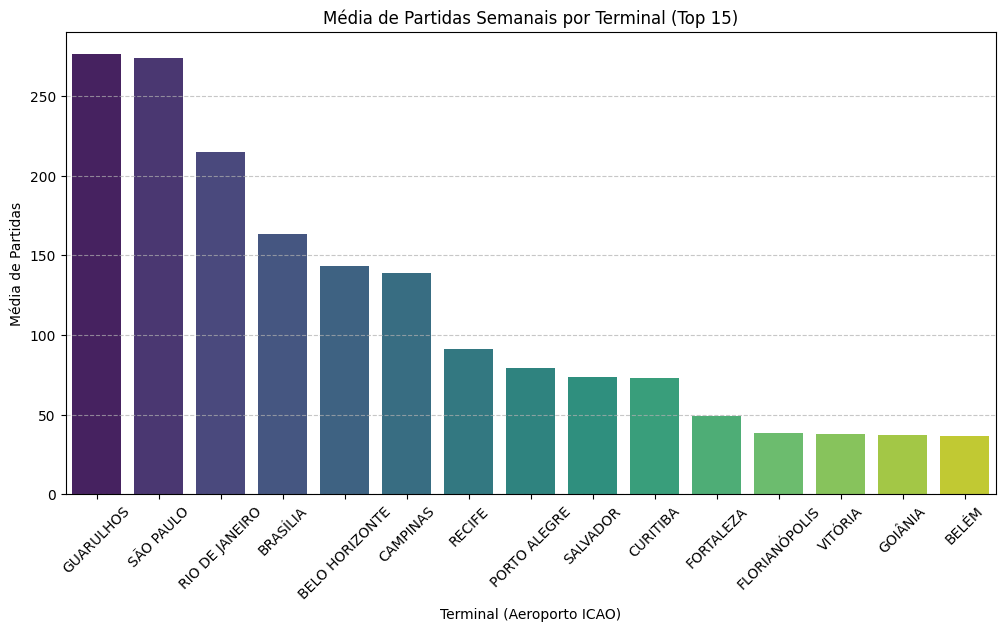

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Agrupando por Aeroporto (Origem) e Semana
# Certifique-se de que 'Sigla ICAO Aeroporto Origem' seja a coluna correta dos terminais
contagem_por_terminal = df_voo.groupby(['origem_cidade', 'semana_do_ano']).size().unstack(fill_value=0)

# Calculando a média de partidas semanal para cada aeroporto
contagem_por_terminal['Média Semanal'] = contagem_por_terminal.mean(axis=1)

# Ordenando pelos aeroportos mais movimentados para facilitar a leitura
contagem_por_terminal = contagem_por_terminal.sort_values(by='Média Semanal', ascending=False)

plt.figure(figsize=(12, 6))

# Plotando os 15 maiores aeroportos para não poluir o gráfico
top_terminais = contagem_por_terminal.head(15)

sns.barplot(x=top_terminais.index, y=top_terminais['Média Semanal'], palette='viridis')

plt.title('Média de Partidas Semanais por Terminal (Top 15)')
plt.xlabel('Terminal (Aeroporto)')
plt.ylabel('Média de Partidas')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

In [29]:
contagem_por_terminal.head(15)

semana_do_ano,2,7,11,15,20,24,28,33,37,41,46,50,Média Semanal
origem_cidade,,,,,,,,,,,,,
GUARULHOS,281,281,281,280,257,276,269,280,282,281,282,264,276.166667
SÃO PAULO,291,291,291,290,245,215,231,291,291,291,290,268,273.750000
RIO DE JANEIRO,225,231,225,228,174,196,190,226,228,222,228,204,214.750000
BRASÍLIA,167,172,173,173,153,149,152,169,171,172,172,141,163.666667
BELO HORIZONTE,158,157,156,155,51,133,140,160,155,153,153,145,143.000000
CAMPINAS,159,153,152,153,12,142,138,159,150,149,152,146,138.750000
RECIFE,100,99,97,98,35,94,88,100,99,98,97,89,91.166667
PORTO ALEGRE,84,87,82,88,48,78,73,84,87,82,88,72,79.416667
SALVADOR,75,77,74,79,60,77,66,76,77,73,79,70,73.583333
